## Data Investigation

In [70]:
import pandas as pd
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.expand_frame_repr", False)
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn as sns
import missingno as msno
import warnings
warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("data.csv")
df.head(5)

,ORDER_ID,CLASS,B_EMAIL,B_TELEFON,B_BIRTHDATE,FLAG_LRIDENTISCH,FLAG_NEWSLETTER,Z_METHODE,Z_CARD_ART,Z_CARD_VALID,...,FAIL_RPLZ,FAIL_RORT,FAIL_RPLZORTMATCH,SESSION_TIME,NEUKUNDE,AMOUNT_ORDER_PRE,VALUE_ORDER_PRE,DATE_LORDER,MAHN_AKT,MAHN_HOECHST
0,49917,no,yes,no,1/17/1973,yes,yes,check,?,5.2006,...,no,no,no,8,yes,0,0.00,?,?,?
1,49919,no,yes,yes,12/8/1970,no,no,credit_card,Visa,12.2007,...,yes,no,no,13,yes,0,0.00,?,?,?
2,49923,no,yes,no,4/3/1972,yes,no,check,?,12.2007,...,no,no,no,3,yes,0,0.00,?,?,?
3,49924,no,no,yes,8/1/1966,yes,no,check,?,1.2007,...,no,no,no,11,no,4,75.72,5/12/2002,0,0
4,49927,no,yes,yes,12/21/1969,yes,no,credit_card,Eurocard,12.2006,...,no,no,no,16,yes,0,0.00,?,?,?


In [5]:
df.shape

(30000, 44)

In [6]:
df.describe()

,ORDER_ID,Z_CARD_VALID,VALUE_ORDER,AMOUNT_ORDER,ANUMMER_01,SESSION_TIME,AMOUNT_ORDER_PRE,VALUE_ORDER_PRE
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,25032.612933,6.680567,43.968058,1.442200,331860.254033,8.577900,0.606700,29.875652
std,14422.306098,3.468332,35.709431,0.921496,147310.846584,3.863448,0.765616,57.382732
min,1.000000,1.200500,5.200000,1.000000,100061.000000,1.000000,0.000000,0.000000
25%,12518.750000,3.200700,17.990000,1.000000,204159.000000,6.000000,0.000000,0.000000
50%,25095.500000,6.200700,34.500000,1.000000,401241.000000,9.000000,0.000000,0.000000
75%,37520.250000,10.200500,57.800000,2.000000,407703.000000,11.000000,1.000000,38.470000
max,50000.000000,12.200700,361.200000,9.000000,609725.000000,24.000000,6.000000,1047.800000


In [8]:
df.dtypes

ORDER_ID               int64
CLASS                    str
B_EMAIL                  str
B_TELEFON                str
B_BIRTHDATE              str
FLAG_LRIDENTISCH         str
FLAG_NEWSLETTER          str
Z_METHODE                str
Z_CARD_ART               str
Z_CARD_VALID         float64
Z_LAST_NAME              str
VALUE_ORDER          float64
WEEKDAY_ORDER            str
TIME_ORDER               str
AMOUNT_ORDER           int64
ANUMMER_01             int64
ANUMMER_02               str
ANUMMER_03               str
ANUMMER_04               str
ANUMMER_05               str
ANUMMER_06               str
ANUMMER_07               str
ANUMMER_08               str
ANUMMER_09               str
ANUMMER_10               str
CHK_LADR                 str
CHK_RADR                 str
CHK_KTO                  str
CHK_CARD                 str
CHK_COOKIE               str
CHK_IP                   str
FAIL_LPLZ                str
FAIL_LORT                str
FAIL_LPLZORTMATCH        str
FAIL_RPLZ     

In [12]:
df.head(5)

,ORDER_ID,CLASS,B_EMAIL,B_TELEFON,B_BIRTHDATE,FLAG_LRIDENTISCH,FLAG_NEWSLETTER,Z_METHODE,Z_CARD_ART,Z_CARD_VALID,Z_LAST_NAME,VALUE_ORDER,WEEKDAY_ORDER,TIME_ORDER,AMOUNT_ORDER,ANUMMER_01,ANUMMER_02,ANUMMER_03,ANUMMER_04,ANUMMER_05,ANUMMER_06,ANUMMER_07,ANUMMER_08,ANUMMER_09,ANUMMER_10,CHK_LADR,CHK_RADR,CHK_KTO,CHK_CARD,CHK_COOKIE,CHK_IP,FAIL_LPLZ,FAIL_LORT,FAIL_LPLZORTMATCH,FAIL_RPLZ,FAIL_RORT,FAIL_RPLZORTMATCH,SESSION_TIME,NEUKUNDE,AMOUNT_ORDER_PRE,VALUE_ORDER_PRE,DATE_LORDER,MAHN_AKT,MAHN_HOECHST
0,49917,no,yes,no,1/17/1973,yes,yes,check,?,5.2006,?,17.80,Saturday,9:13:00 AM,1,406811,?,?,?,?,?,?,?,?,?,no,no,no,no,no,no,no,no,no,no,no,no,8,yes,0,0.00,?,?,?
1,49919,no,yes,yes,12/8/1970,no,no,credit_card,Visa,12.2007,yes,18.20,Wednesday,5:36:00 PM,1,600953,?,?,?,?,?,?,?,?,?,no,no,no,no,no,no,no,no,no,yes,no,no,13,yes,0,0.00,?,?,?
2,49923,no,yes,no,4/3/1972,yes,no,check,?,12.2007,?,10.80,Friday,11:13:00 AM,1,406310,?,?,?,?,?,?,?,?,?,no,no,no,no,no,no,no,no,no,no,no,no,3,yes,0,0.00,?,?,?
3,49924,no,no,yes,8/1/1966,yes,no,check,?,1.2007,?,54.50,Friday,2:07:00 AM,1,307359,?,?,?,?,?,?,?,?,?,no,no,no,yes,no,no,no,no,no,no,no,no,11,no,4,75.72,5/12/2002,0,0
4,49927,no,yes,yes,12/21/1969,yes,no,credit_card,Eurocard,12.2006,yes,19.99,Tuesday,11:46:00 PM,1,200767,?,?,?,?,?,?,?,?,?,no,no,no,no,no,no,no,no,no,no,no,no,16,yes,0,0.00,?,?,?


In [13]:
# info on dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 44 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ORDER_ID           30000 non-null  int64  
 1   CLASS              30000 non-null  str    
 2   B_EMAIL            30000 non-null  str    
 3   B_TELEFON          30000 non-null  str    
 4   B_BIRTHDATE        30000 non-null  str    
 5   FLAG_LRIDENTISCH   30000 non-null  str    
 6   FLAG_NEWSLETTER    30000 non-null  str    
 7   Z_METHODE          30000 non-null  str    
 8   Z_CARD_ART         30000 non-null  str    
 9   Z_CARD_VALID       30000 non-null  float64
 10  Z_LAST_NAME        30000 non-null  str    
 11  VALUE_ORDER        30000 non-null  float64
 12  WEEKDAY_ORDER      30000 non-null  str    
 13  TIME_ORDER         29980 non-null  str    
 14  AMOUNT_ORDER       30000 non-null  int64  
 15  ANUMMER_01         30000 non-null  int64  
 16  ANUMMER_02         30000 non-null

<Axes: >

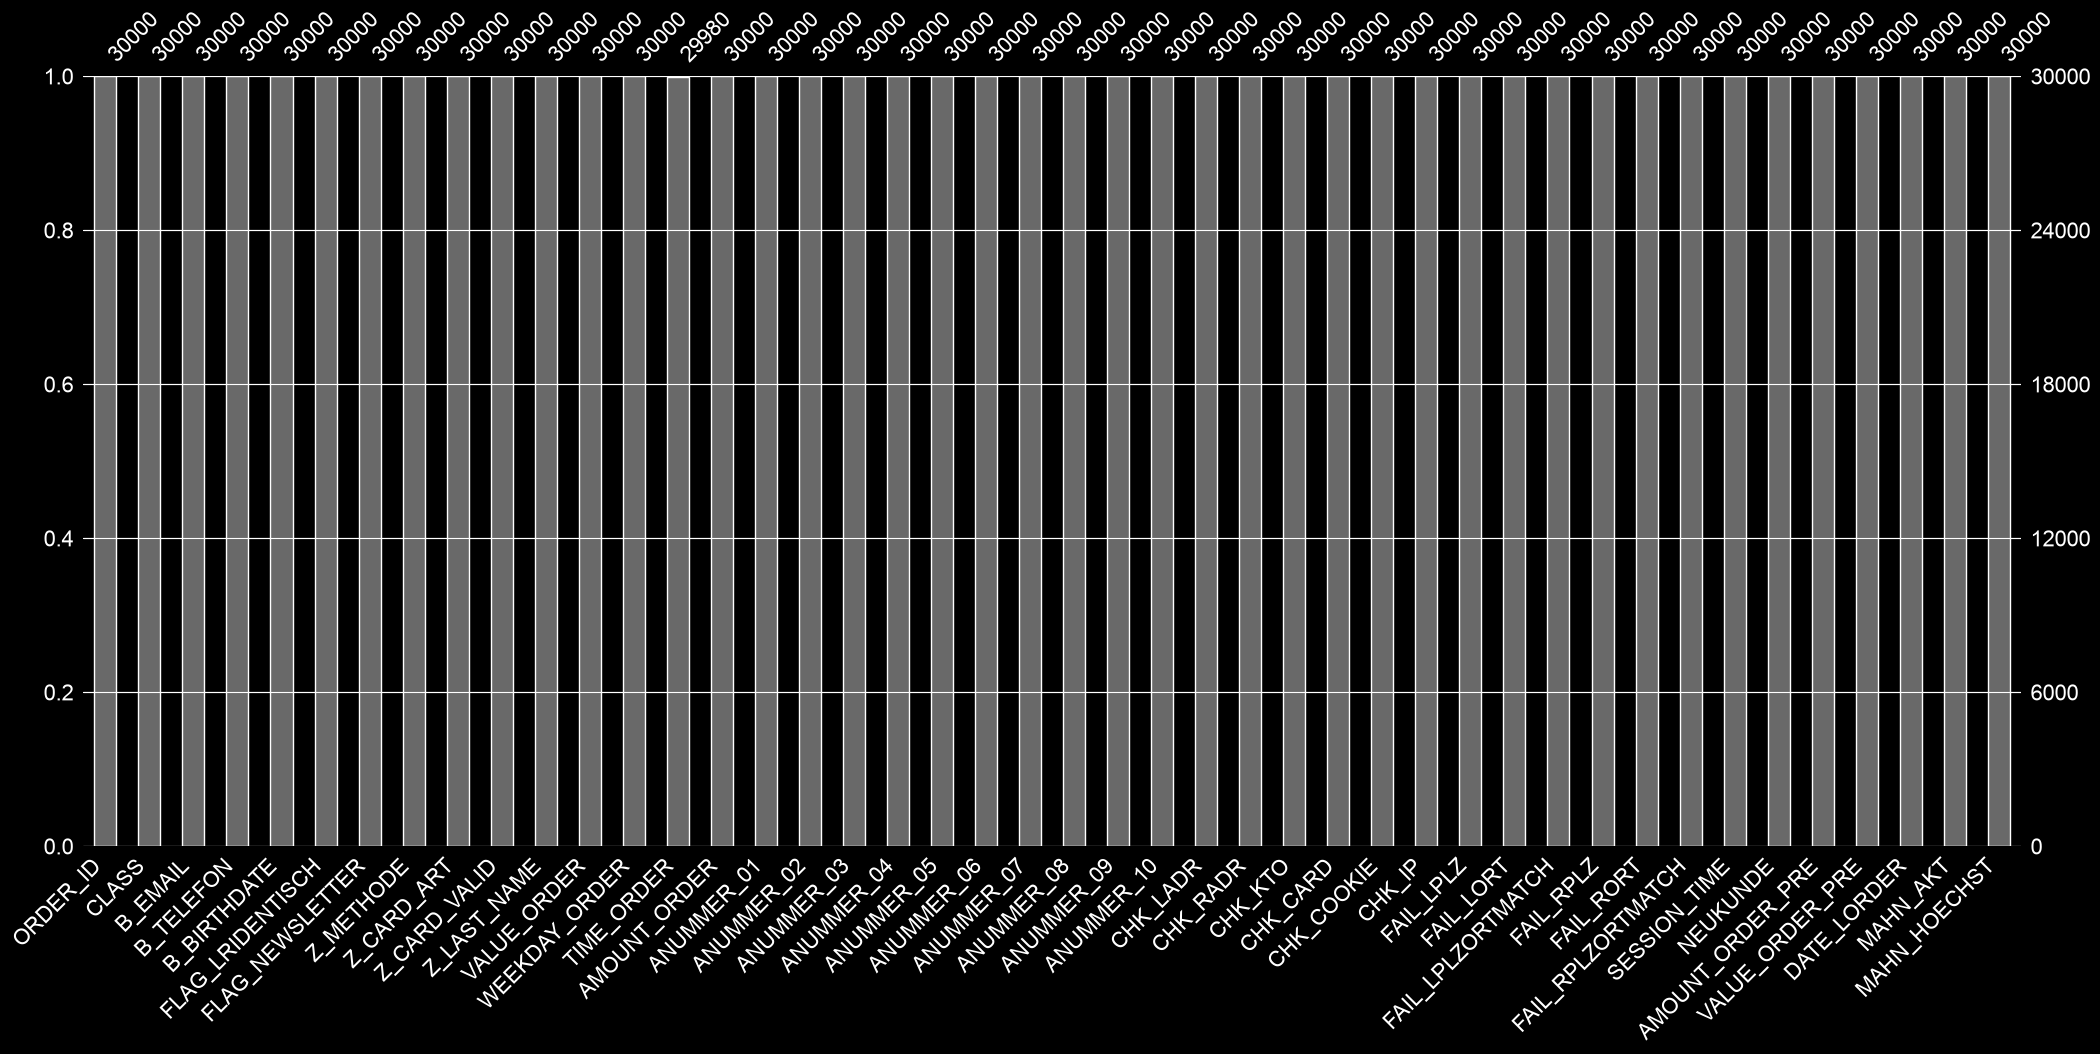

In [14]:
# visualize missing values
msno.bar(df)

In [15]:
# Replace "?" to missing values
df.replace("?", np.nan, inplace=True)

,ORDER_ID,CLASS,B_EMAIL,B_TELEFON,B_BIRTHDATE,FLAG_LRIDENTISCH,FLAG_NEWSLETTER,Z_METHODE,Z_CARD_ART,Z_CARD_VALID,Z_LAST_NAME,VALUE_ORDER,WEEKDAY_ORDER,TIME_ORDER,AMOUNT_ORDER,ANUMMER_01,ANUMMER_02,ANUMMER_03,ANUMMER_04,ANUMMER_05,ANUMMER_06,ANUMMER_07,ANUMMER_08,ANUMMER_09,ANUMMER_10,CHK_LADR,CHK_RADR,CHK_KTO,CHK_CARD,CHK_COOKIE,CHK_IP,FAIL_LPLZ,FAIL_LORT,FAIL_LPLZORTMATCH,FAIL_RPLZ,FAIL_RORT,FAIL_RPLZORTMATCH,SESSION_TIME,NEUKUNDE,AMOUNT_ORDER_PRE,VALUE_ORDER_PRE,DATE_LORDER,MAHN_AKT,MAHN_HOECHST
0,49917,no,yes,no,1/17/1973,yes,yes,check,NaN,5.2006,NaN,17.80,Saturday,9:13:00 AM,1,406811,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,no,no,no,no,no,no,no,no,no,no,no,8,yes,0,0.00,NaN,NaN,NaN
1,49919,no,yes,yes,12/8/1970,no,no,credit_card,Visa,12.2007,yes,18.20,Wednesday,5:36:00 PM,1,600953,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,no,no,no,no,no,no,no,no,yes,no,no,13,yes,0,0.00,NaN,NaN,NaN
2,49923,no,yes,no,4/3/1972,yes,no,check,NaN,12.2007,NaN,10.80,Friday,11:13:00 AM,1,406310,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,no,no,no,no,no,no,no,no,no,no,no,3,yes,0,0.00,NaN,NaN,NaN
3,49924,no,no,yes,8/1/1966,yes,no,check,NaN,1.2007,NaN,54.50,Friday,2:07:00 AM,1,307359,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,no,no,yes,no,no,no,no,no,no,no,no,11,no,4,75.72,5/12/2002,0,0
4,49927,no,yes,yes,12/21/1969,yes,no,credit_card,Eurocard,12.2006,yes,19.99,Tuesday,11:46:00 PM,1,200767,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,no,no,no,no,no,no,no,no,no,no,no,16,yes,0,0.00,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,49821,no,yes,no,3/3/1981,yes,no,check,NaN,6.2005,NaN,18.20,Sunday,6:21:00 PM,1,406859,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,no,no,no,no,no,no,no,no,no,no,no,10,no,1,40.83,3/9/2002,0,3
29996,49824,no,yes,no,2/21/1972,no,no,credit_card,Eurocard,5.2005,yes,12.60,Saturday,3:51:00 PM,1,206507,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,no,no,no,no,no,no,no,no,no,no,no,10,no,2,52.84,6/3/2001,0,0
29997,49825,no,yes,no,6/11/1980,no,no,credit_card,Eurocard,11.2006,yes,32.80,Monday,10:37:00 AM,1,500767,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,no,no,no,no,no,no,no,no,no,no,no,6,yes,0,0.00,NaN,NaN,NaN
29998,49828,no,yes,no,12/4/1980,no,no,credit_card,Visa,4.2005,yes,5.20,Sunday,1:52:00 AM,1,502611,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,no,no,no,no,no,no,no,no,no,no,no,6,no,1,42.92,7/1/2001,0,0


In [16]:
df.isnull().sum()

ORDER_ID                 0
CLASS                    0
B_EMAIL                  0
B_TELEFON                0
B_BIRTHDATE           2942
FLAG_LRIDENTISCH         0
FLAG_NEWSLETTER          0
Z_METHODE                0
Z_CARD_ART           18654
Z_CARD_VALID             0
Z_LAST_NAME          14808
VALUE_ORDER              0
WEEKDAY_ORDER            0
TIME_ORDER              20
AMOUNT_ORDER             0
ANUMMER_01               0
ANUMMER_02           22147
ANUMMER_03           26802
ANUMMER_04           28668
ANUMMER_05           29459
ANUMMER_06           29794
ANUMMER_07           29905
ANUMMER_08           29966
ANUMMER_09           29993
ANUMMER_10           30000
CHK_LADR                 0
CHK_RADR                 0
CHK_KTO                  0
CHK_CARD                 0
CHK_COOKIE               0
CHK_IP                   0
FAIL_LPLZ                0
FAIL_LORT                0
FAIL_LPLZORTMATCH        0
FAIL_RPLZ                0
FAIL_RORT                0
FAIL_RPLZORTMATCH        0
S

In [24]:
# Extract Numeric Column
num_cols = df.select_dtypes(include = ["int64", "float64"])

num_cols.head()

,ORDER_ID,Z_CARD_VALID,VALUE_ORDER,AMOUNT_ORDER,ANUMMER_01,SESSION_TIME,AMOUNT_ORDER_PRE,VALUE_ORDER_PRE
0,49917,5.2006,17.80,1,406811,8,0,0.00
1,49919,12.2007,18.20,1,600953,13,0,0.00
2,49923,12.2007,10.80,1,406310,3,0,0.00
3,49924,1.2007,54.50,1,307359,11,4,75.72
4,49927,12.2006,19.99,1,200767,16,0,0.00


In [26]:
# check for negative values
num_cols.describe()

,ORDER_ID,Z_CARD_VALID,VALUE_ORDER,AMOUNT_ORDER,ANUMMER_01,SESSION_TIME,AMOUNT_ORDER_PRE,VALUE_ORDER_PRE
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,25032.612933,6.680567,43.968058,1.442200,331860.254033,8.577900,0.606700,29.875652
std,14422.306098,3.468332,35.709431,0.921496,147310.846584,3.863448,0.765616,57.382732
min,1.000000,1.200500,5.200000,1.000000,100061.000000,1.000000,0.000000,0.000000
25%,12518.750000,3.200700,17.990000,1.000000,204159.000000,6.000000,0.000000,0.000000
50%,25095.500000,6.200700,34.500000,1.000000,401241.000000,9.000000,0.000000,0.000000
75%,37520.250000,10.200500,57.800000,2.000000,407703.000000,11.000000,1.000000,38.470000
max,50000.000000,12.200700,361.200000,9.000000,609725.000000,24.000000,6.000000,1047.800000


In [27]:
#Extract Categorical Column

cat_cols = df.select_dtypes(include = ["object", "category"])

## Exploratory Data Analysis

Univariate Analysis

CLASS
no     94.18
yes     5.82
Name: proportion, dtype: float64


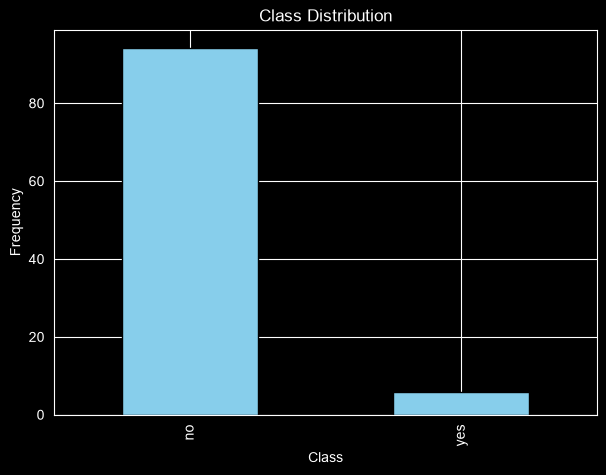

In [44]:
# Check Class Imbalance
count_class = (
    cat_cols["CLASS"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(count_class)
# create bar chart
# Setting figure
plt.figure(figsize = (7,5))
# Plot the bar
count_class.plot(kind="bar", color='skyblue', edgecolor='black')

# Name bar
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Frequency")
plt.show()

### Analysis

The target variable is highly imbalanced, with approximately 94.2% of customers classified as **not high risk** and 5.8% classified as **high risk**. This indicates that high-risk orders are the minority class.

The **5.8% high-risk rate** serves as the baseline prevalence of the positive class and will be used as a reference point when evaluating feature relationships throughout the EDA. This class imbalance should also be considered during model development, as accuracy alone may be misleading. Instead, evaluation metrics such as Precision, Recall, F1-score, and ROC-AUC will provide a more reliable assessment of model performance.

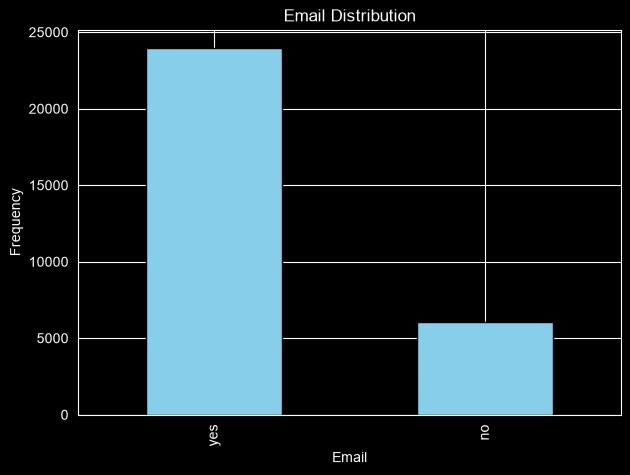

In [31]:
# Is it common for email to be submitted with an order?
count_email = df["B_EMAIL"].value_counts()
plt.figure(figsize = (7,5))
count_email.plot(kind="bar", color='skyblue', edgecolor='black')
plt.title("Email Distribution")
plt.xlabel("Email")
plt.ylabel("Frequency")
plt.show()


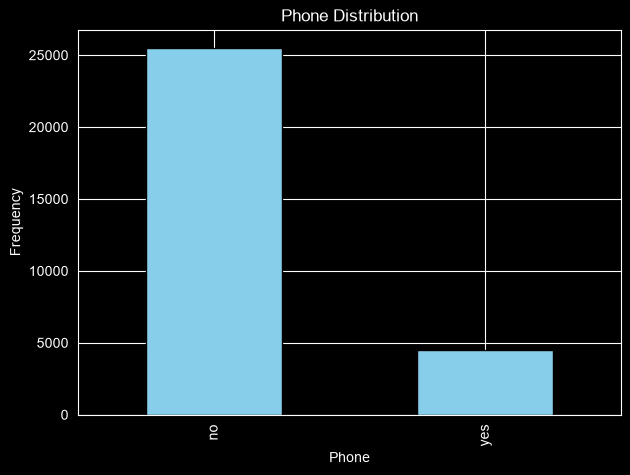

In [35]:
# Is it common for phone to be submitted with an order?
count_email = df["B_TELEFON"].value_counts()
plt.figure(figsize = (7,5))
count_email.plot(kind="bar", color='skyblue', edgecolor='black')
plt.title("Phone Distribution")
plt.xlabel("Phone")
plt.ylabel("Frequency")
plt.show()

## Contact Details Feature Analysis

The majority of customers submitted an email address with their order, whereas fewer customers provided a phone number. At this stage, this analysis describes the overall distribution of these features only. Further bivariate analysis with the target variable (`CLASS`) will determine whether the presence or absence of an email address or phone number is associated with a higher likelihood of a high-risk order.

In [36]:
# Concat numeric and categorical
df1 = pd.concat([num_cols, cat_cols] ,axis=1)
df1.head(5)

,ORDER_ID,Z_CARD_VALID,VALUE_ORDER,AMOUNT_ORDER,ANUMMER_01,SESSION_TIME,AMOUNT_ORDER_PRE,VALUE_ORDER_PRE,CLASS,B_EMAIL,B_TELEFON,B_BIRTHDATE,FLAG_LRIDENTISCH,FLAG_NEWSLETTER,Z_METHODE,Z_CARD_ART,Z_LAST_NAME,WEEKDAY_ORDER,TIME_ORDER,ANUMMER_02,ANUMMER_03,ANUMMER_04,ANUMMER_05,ANUMMER_06,ANUMMER_07,ANUMMER_08,ANUMMER_09,ANUMMER_10,CHK_LADR,CHK_RADR,CHK_KTO,CHK_CARD,CHK_COOKIE,CHK_IP,FAIL_LPLZ,FAIL_LORT,FAIL_LPLZORTMATCH,FAIL_RPLZ,FAIL_RORT,FAIL_RPLZORTMATCH,NEUKUNDE,DATE_LORDER,MAHN_AKT,MAHN_HOECHST
0,49917,5.2006,17.80,1,406811,8,0,0.00,no,yes,no,1/17/1973,yes,yes,check,NaN,NaN,Saturday,9:13:00 AM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,no,no,no,no,no,no,no,no,no,no,no,yes,NaN,NaN,NaN
1,49919,12.2007,18.20,1,600953,13,0,0.00,no,yes,yes,12/8/1970,no,no,credit_card,Visa,yes,Wednesday,5:36:00 PM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,no,no,no,no,no,no,no,no,yes,no,no,yes,NaN,NaN,NaN
2,49923,12.2007,10.80,1,406310,3,0,0.00,no,yes,no,4/3/1972,yes,no,check,NaN,NaN,Friday,11:13:00 AM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,no,no,no,no,no,no,no,no,no,no,no,yes,NaN,NaN,NaN
3,49924,1.2007,54.50,1,307359,11,4,75.72,no,no,yes,8/1/1966,yes,no,check,NaN,NaN,Friday,2:07:00 AM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,no,no,yes,no,no,no,no,no,no,no,no,no,5/12/2002,0,0
4,49927,12.2006,19.99,1,200767,16,0,0.00,no,yes,yes,12/21/1969,yes,no,credit_card,Eurocard,yes,Tuesday,11:46:00 PM,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,no,no,no,no,no,no,no,no,no,no,no,yes,NaN,NaN,NaN


## Bivariate Analysis and Feature Selection

B_EMAIL
yes    79.88
no     20.12
Name: proportion, dtype: float64
CLASS       no   yes
B_EMAIL             
no       90.18  9.82
yes      95.19  4.81


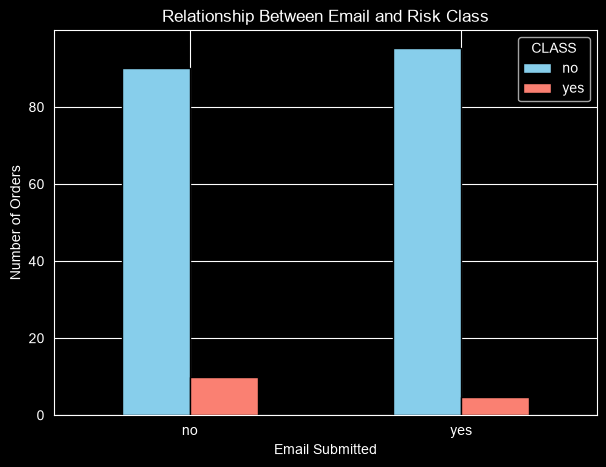

In [46]:
# Relationship between email availability and the target variable (CLASS)
email_count = (cat_cols["B_EMAIL"].value_counts(normalize=True).mul(100).round(2))
print(email_count)
email_class_percent = (
    pd.crosstab(df["B_EMAIL"], df["CLASS"], normalize="index") * 100
).round(2)

print(email_class_percent)
email_class_percent.plot(
    kind="bar",
    figsize=(7, 5),
    color=["skyblue", "salmon"],
    edgecolor="black"
)

plt.title("Relationship Between Email and Risk Class")
plt.xlabel("Email Submitted")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.legend(title="CLASS")
plt.show()

### Analysis and Feature Selection

Approximately 20.2% of customers did not provide an email address when placing an order. Within this group, the high-risk rate is 9.82%, which is substantially higher than the overall dataset baseline of 5.8%. In comparison, customers who provided an email address have a high-risk rate of only 4.81%.

This suggests that the absence of an email address is associated with an increased likelihood of a high-risk order. Therefore, **B_EMAIL** appears to be a potentially informative feature and will be retained for model development.

**Feature Decision:** ✅ Keep

**Reason:** Customers without an email address exhibit a high-risk rate (9.82%) that is substantially higher than both the overall baseline (5.8%) and customers who provided an email address (4.81%). This indicates that B_EMAIL may provide useful predictive information.

B_TELEFON
no     84.98
yes    15.02
Name: proportion, dtype: float64
CLASS         no   yes
B_TELEFON             
no         93.70  6.30
yes        96.87  3.13


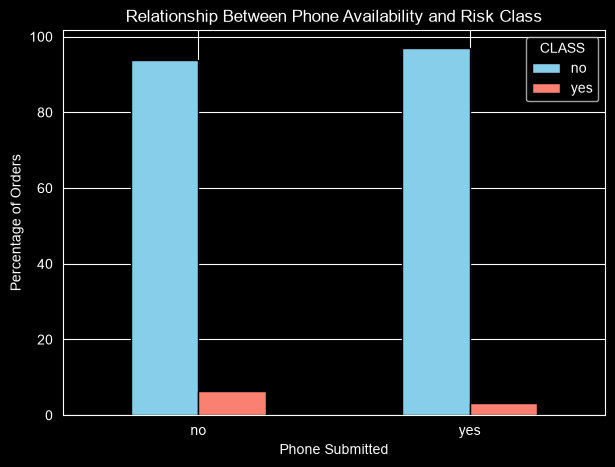

In [47]:
# Relationship between phone availability and the target variable (CLASS)

phone_count = (
    cat_cols["B_TELEFON"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(phone_count)

phone_class_percent = (
    pd.crosstab(df["B_TELEFON"], df["CLASS"], normalize="index") * 100
).round(2)

print(phone_class_percent)

phone_class_percent.plot(
    kind="bar",
    figsize=(7,5),
    color=["skyblue", "salmon"],
    edgecolor="black"
)

plt.title("Relationship Between Phone Availability and Risk Class")
plt.xlabel("Phone Submitted")
plt.ylabel("Percentage of Orders")
plt.xticks(rotation=0)
plt.legend(title="CLASS")
plt.show()

### Analysis and Feature Selection

Approximately 85% of customers did not provide a telephone number when placing an order. Within this group, the high-risk rate is 6.30%, which is slightly higher than the overall dataset baseline of 5.8%. In comparison, customers who provided a telephone number have a substantially lower high-risk rate of 3.13%.

These results suggest that providing a telephone number is associated with a lower likelihood of a high-risk order. Conversely, the absence of a telephone number may indicate an increased level of risk. Therefore, **B_TELEFON** appears to be a potentially informative feature and will be retained for model development.

**Feature Decision:** ✅ Keep

**Reason:** Customers who did not provide a telephone number exhibit a higher high-risk rate (6.30%) than the overall dataset baseline (5.8%), while customers who provided a telephone number have a considerably lower high-risk rate (3.13%). This suggests that **B_TELEFON** may provide useful predictive information for identifying high-risk orders.

FLAG_LRIDENTISCH
yes    70.52
no     29.48
Name: proportion, dtype: float64
CLASS                no   yes
FLAG_LRIDENTISCH             
no                94.29  5.71
yes               94.13  5.87


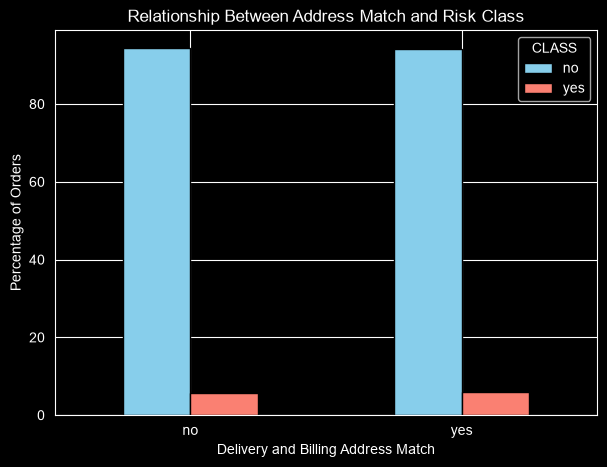

In [48]:
# Relationship between delivery/billing address match and CLASS

address_match_count = (
    cat_cols["FLAG_LRIDENTISCH"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(address_match_count)

address_match_percent = (
    pd.crosstab(df["FLAG_LRIDENTISCH"], df["CLASS"], normalize="index") * 100
).round(2)

print(address_match_percent)

address_match_percent.plot(
    kind="bar",
    figsize=(7,5),
    color=["skyblue","salmon"],
    edgecolor="black"
)

plt.title("Relationship Between Address Match and Risk Class")
plt.xlabel("Delivery and Billing Address Match")
plt.ylabel("Percentage of Orders")
plt.xticks(rotation=0)
plt.legend(title="CLASS")
plt.show()

### Analysis and Feature Selection

Approximately 70.5% of customers used the same delivery and billing address, while 29.5% used different addresses. The high-risk rate is 5.87% for customers whose delivery and billing addresses match and 5.71% for customers whose addresses do not match. Both values are nearly identical to the overall dataset baseline of 5.8%.

These results suggest that whether the delivery and billing addresses match has little to no association with the likelihood of a high-risk order. Based on the current analysis, this feature does not appear to provide meaningful discriminatory power.

**Feature Decision:** ⚠️ Low Predictive Value

**Reason:** The high-risk rates for both groups are almost identical (5.87% vs. 5.71%) and closely match the overall baseline (5.8%). This indicates that `FLAG_LRIDENTISCH` contributes little information for distinguishing between high-risk and low-risk orders. The feature may be retained for initial model training, but it is unlikely to be an important predictor.

Z_LAST_NAME
yes    95.03
no      4.97
Name: proportion, dtype: float64
CLASS           no   yes
Z_LAST_NAME             
no           91.66  8.34
yes          95.10  4.90


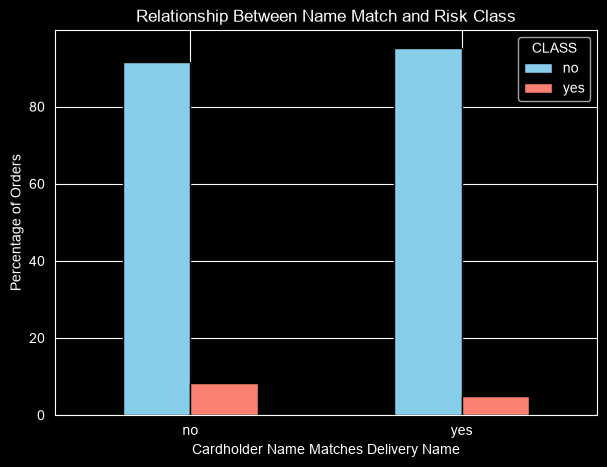

In [49]:
# Relationship between name match and CLASS

name_match_count = (
    cat_cols["Z_LAST_NAME"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(name_match_count)

name_match_percent = (
    pd.crosstab(df["Z_LAST_NAME"], df["CLASS"], normalize="index") * 100
).round(2)

print(name_match_percent)

name_match_percent.plot(
    kind="bar",
    figsize=(7,5),
    color=["skyblue","salmon"],
    edgecolor="black"
)

plt.title("Relationship Between Name Match and Risk Class")
plt.xlabel("Cardholder Name Matches Delivery Name")
plt.ylabel("Percentage of Orders")
plt.xticks(rotation=0)
plt.legend(title="CLASS")
plt.show()

### Analysis and Feature Selection

Approximately 95.0% of customers have matching account/cardholder and delivery names, while only 5.0% have different names. Customers whose names do not match have a high-risk rate of 8.34%, which is considerably higher than the overall dataset baseline of 5.8%. In contrast, customers with matching names have a lower high-risk rate of 4.90%.

These results suggest that a mismatch between the account/cardholder name and the delivery name is associated with an increased likelihood of a high-risk order. Although name mismatches are relatively uncommon, they exhibit a noticeably higher proportion of high-risk orders, indicating that this feature may provide valuable predictive information.

**Feature Decision:** ✅ Keep

**Reason:** Orders with non-matching names have a substantially higher high-risk rate (8.34%) than both the overall dataset baseline (5.8%) and orders with matching names (4.90%). This indicates that **Z_LAST_NAME** is likely to be a useful predictor for identifying high-risk orders.

NEUKUNDE
yes    50.11
no     49.89
Name: proportion, dtype: float64
CLASS        no   yes
NEUKUNDE             
no        96.49  3.51
yes       91.88  8.12


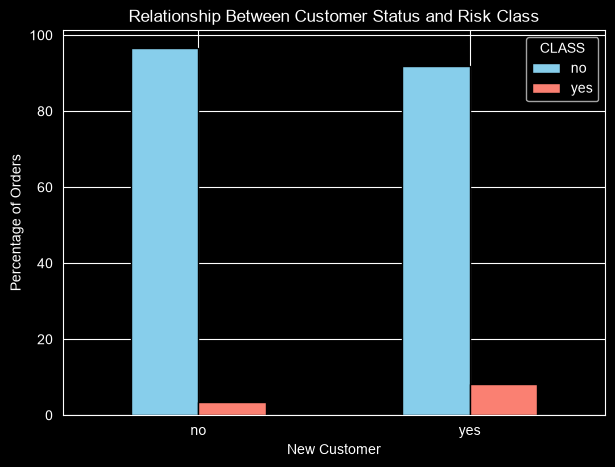

In [50]:
# Relationship between new customer status and CLASS

new_customer_count = (
    cat_cols["NEUKUNDE"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(new_customer_count)

new_customer_percent = (
    pd.crosstab(df["NEUKUNDE"], df["CLASS"], normalize="index") * 100
).round(2)

print(new_customer_percent)

new_customer_percent.plot(
    kind="bar",
    figsize=(7,5),
    color=["skyblue","salmon"],
    edgecolor="black"
)

plt.title("Relationship Between Customer Status and Risk Class")
plt.xlabel("New Customer")
plt.ylabel("Percentage of Orders")
plt.xticks(rotation=0)
plt.legend(title="CLASS")
plt.show()

### Analysis and Feature Selection

The customer base is almost evenly split, with approximately 50.1% new customers and 49.9% returning customers. New customers have a high-risk rate of 8.12%, which is considerably higher than the overall dataset baseline of 5.8%. In contrast, returning customers have a substantially lower high-risk rate of 3.51%.

These results suggest that customer status is strongly associated with the likelihood of a high-risk order. New customers appear to present a significantly higher level of risk than returning customers, making this feature a valuable indicator for identifying potentially high-risk transactions.

**Feature Decision:** ✅ Keep

**Reason:** New customers exhibit a high-risk rate of 8.12%, which is more than twice that of returning customers (3.51%) and substantially higher than the overall dataset baseline (5.8%). This indicates that **NEUKUNDE** is likely to be a strong predictor of high-risk orders and should be retained for model development.

CHK_IP
no     99.6
yes     0.4
Name: proportion, dtype: float64
CLASS      no    yes
CHK_IP              
no      94.23   5.77
yes     81.82  18.18


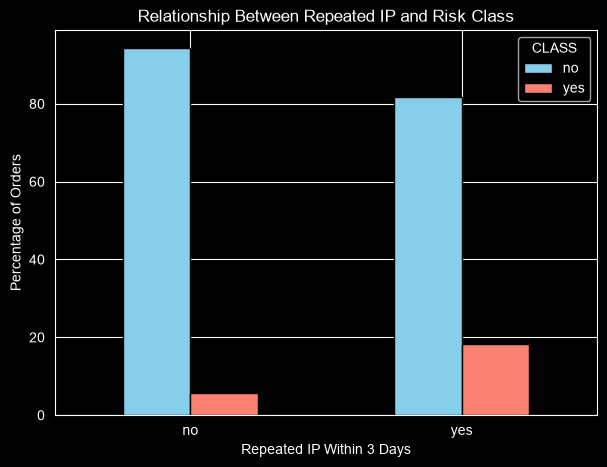

In [51]:
# Relationship between repeated IP address and CLASS

ip_count = (
    cat_cols["CHK_IP"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(ip_count)

ip_class_percent = (
    pd.crosstab(df["CHK_IP"], df["CLASS"], normalize="index") * 100
).round(2)

print(ip_class_percent)

ip_class_percent.plot(
    kind="bar",
    figsize=(7,5),
    color=["skyblue","salmon"],
    edgecolor="black"
)

plt.title("Relationship Between Repeated IP and Risk Class")
plt.xlabel("Repeated IP Within 3 Days")
plt.ylabel("Percentage of Orders")
plt.xticks(rotation=0)
plt.legend(title="CLASS")
plt.show()

### Analysis and Feature Selection

Approximately 99.6% of orders originated from unique IP addresses, while only 0.4% of orders shared the same IP address within a three-day period. Although repeated IP addresses are rare, they exhibit a high-risk rate of 18.18%, which is more than three times the overall dataset baseline of 5.8%. In comparison, orders without a repeated IP address have a high-risk rate of 5.77%, which is nearly identical to the dataset baseline.

These findings suggest that repeated IP addresses are strongly associated with an increased likelihood of a high-risk order. While this event occurs infrequently, its substantially higher proportion of high-risk orders indicates that it is a valuable indicator of potentially fraudulent activity.

**Feature Decision:** ✅ Keep

**Reason:** Orders associated with a repeated IP address have a high-risk rate of 18.18%, compared with 5.77% for orders without a repeated IP address. This strong difference indicates that **CHK_IP** is likely to be a highly informative predictor of high-risk orders and should be retained for model development.

## Summary of Categorical Feature Analysis

The table below summarizes the relationship between the analyzed categorical features and the target variable (`CLASS`). The predictive strength is based on the observed difference in high-risk rates relative to the overall dataset baseline of **5.8%**.

| Feature | High-Risk Rate | Predictive Strength | Decision |
|----------|---------------:|---------------------|----------|
| `CHK_IP` | 18.18% (Repeated IP) vs. 5.77% (Unique IP) | Very Strong | ✅ Keep |
| `B_EMAIL` | 9.82% (No Email) vs. 4.81% (Email) | Strong | ✅ Keep |
| `Z_LAST_NAME` | 8.34% (Names Do Not Match) vs. 4.90% (Names Match) | Strong | ✅ Keep |
| `NEUKUNDE` | 8.12% (New Customer) vs. 3.51% (Returning Customer) | Strong | ✅ Keep |
| `B_TELEFON` | 6.30% (No Phone) vs. 3.13% (Phone) | Moderate | ✅ Keep |
| `FLAG_LRIDENTISCH` | 5.87% (Address Match) vs. 5.71% (No Match) | Weak | ⚠️ Low Predictive Value |

### Key Findings

- **Repeated IP addresses (`CHK_IP`)** exhibit the strongest relationship with high-risk orders, with a high-risk rate more than three times the overall dataset baseline.
- **Email availability, customer status (`NEUKUNDE`), and name matching (`Z_LAST_NAME`)** all demonstrate meaningful associations with the target variable and should be retained for model development.
- **Telephone availability (`B_TELEFON`)** shows a moderate relationship with high-risk orders and may still contribute useful predictive information.
- **Matching delivery and billing addresses (`FLAG_LRIDENTISCH`)** show almost no difference in high-risk rates, suggesting limited predictive value. This feature can be retained initially, but its importance should be confirmed during model training.

# EDA for numerical values

count    30000.000000
mean        43.968058
std         35.709431
min          5.200000
25%         17.990000
50%         34.500000
75%         57.800000
max        361.200000
Name: VALUE_ORDER, dtype: float64


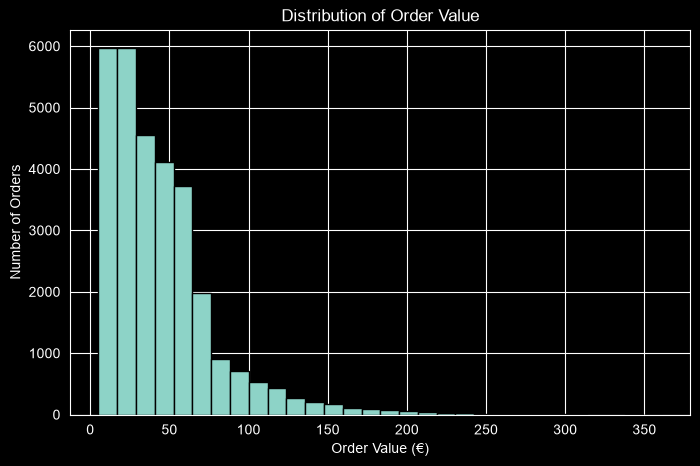

<Figure size 600x500 with 0 Axes>

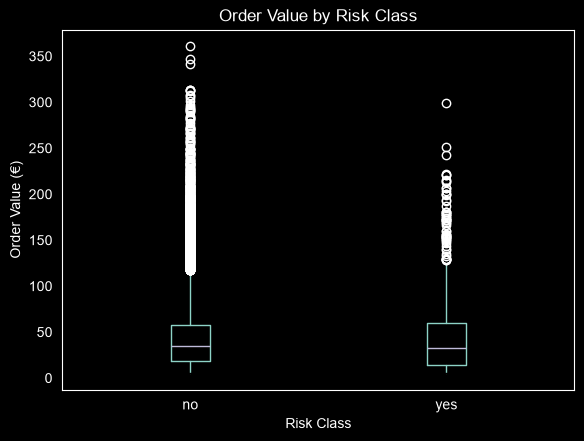

,count,mean,std,min,25%,50%,75%,max
CLASS,,,,,,,,
no,28254.0,44.027979,35.597744,5.2,18.0,34.50,57.8000,361.2
yes,1746.0,42.998402,37.467853,5.2,14.5,32.75,59.3925,299.2


In [55]:
# ORDER VALUES

value_order_distribution = num_cols["VALUE_ORDER"].describe()
print(value_order_distribution)

#plotting histogram for value orders

plt.figure(figsize=(8, 5))

plt.hist(
    df1["VALUE_ORDER"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Order Value")
plt.xlabel("Order Value (€)")
plt.ylabel("Number of Orders")

plt.show()

# Plotting boxplot
plt.figure(figsize=(6, 5))

df1.boxplot(
    column="VALUE_ORDER",
    by="CLASS",
    grid=False
)

plt.title("Order Value by Risk Class")
plt.suptitle("")  # Removes the automatic pandas title
plt.xlabel("Risk Class")
plt.ylabel("Order Value (€)")

plt.show()

# Summary statistics
df.groupby("CLASS")["VALUE_ORDER"].mul(100).describe()


### Analysis and Observation
The distribution of VALUE_ORDER is positively skewed, with most orders concentrated at lower values and a small number of high-value outliers extending the right tail. Comparison across the two risk classes reveals very similar means, medians, quartiles, and standard deviations. The substantial overlap in the distributions indicates that order value alone provides limited separation between high-risk and low-risk orders. Although VALUE_ORDER may still contribute predictive information when combined with other variables, it does not appear to be a strong standalone predictor of order risk.

Decision: ✅ Keep (for now)

Reason: While VALUE_ORDER shows limited standalone predictive power, numerical features can still improve model performance when combined with other variables. Its importance should be evaluated during feature selection and model training rather than being removed solely based on univariate and bivariate EDA.

count    30000.000000
mean         8.577900
std          3.863448
min          1.000000
25%          6.000000
50%          9.000000
75%         11.000000
max         24.000000
Name: SESSION_TIME, dtype: float64


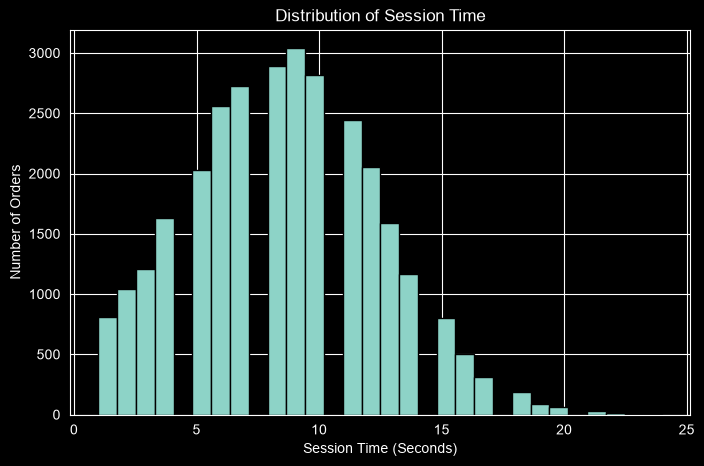

<Figure size 600x500 with 0 Axes>

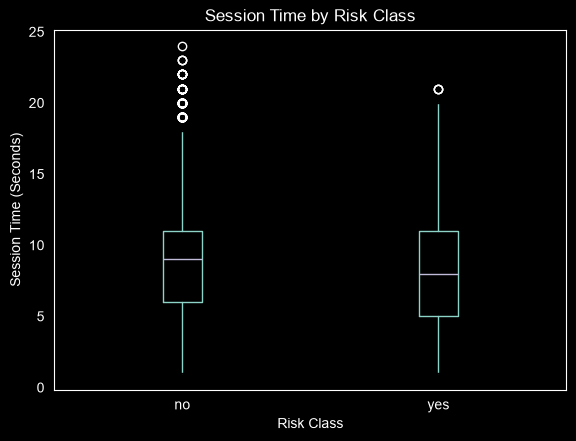

,count,mean,std,min,25%,50%,75%,max
CLASS,,,,,,,,
no,28254.0,8.632194,3.839236,1.0,6.0,9.0,11.0,24.0
yes,1746.0,7.699313,4.139345,1.0,5.0,8.0,11.0,21.0


In [61]:


# Summary Statistics
print(df1["SESSION_TIME"].describe())

# Histogram
plt.figure(figsize=(8,5))

plt.hist(
    df["SESSION_TIME"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Session Time")
plt.xlabel("Session Time (Seconds)")
plt.ylabel("Number of Orders")

plt.show()

# Boxplot by CLASS
plt.figure(figsize=(6,5))

df1.boxplot(
    column="SESSION_TIME",
    by="CLASS",
    grid=False
)

plt.title("Session Time by Risk Class")
plt.suptitle("")
plt.xlabel("Risk Class")
plt.ylabel("Session Time (Seconds)")

plt.show()

# Summary statistics by class
display(df1.groupby("CLASS")["SESSION_TIME"].describe())

### Analysis and Interpretation

The distribution of **`SESSION_TIME`** is approximately bell-shaped with a slight positive (right) skew. Most customer sessions are concentrated between **5 and 12 seconds**, while relatively few sessions extend beyond this range. A small number of longer session times create a modest right tail, indicating the presence of a few high-duration outliers.

Comparison of session time across the two risk classes reveals substantial overlap in their distributions. However, high-risk orders exhibit **slightly lower mean and median session times** than low-risk orders. The average session time for high-risk orders is **7.70 seconds**, compared with **8.63 seconds** for low-risk orders, while the median session time is **8 seconds** for high-risk orders and **9 seconds** for low-risk orders. The similar interquartile ranges and standard deviations indicate that the overall variability is comparable between the two groups.

These findings suggest that customers associated with high-risk orders tend to complete their sessions slightly more quickly than customers associated with low-risk orders. Although the difference is relatively modest and the distributions overlap considerably, `SESSION_TIME` demonstrates some ability to distinguish between the two classes and may provide useful predictive information when combined with other features.

**Feature Decision:** ✅ Keep

**Reason:** While `SESSION_TIME` does not provide strong separation between high-risk and low-risk orders on its own, the consistent difference in central tendency suggests that it may contribute valuable information when used alongside other predictive features. Its overall importance should be further evaluated during feature selection and model development.

count    30000.000000
mean         1.442200
std          0.921496
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          9.000000
Name: AMOUNT_ORDER, dtype: float64


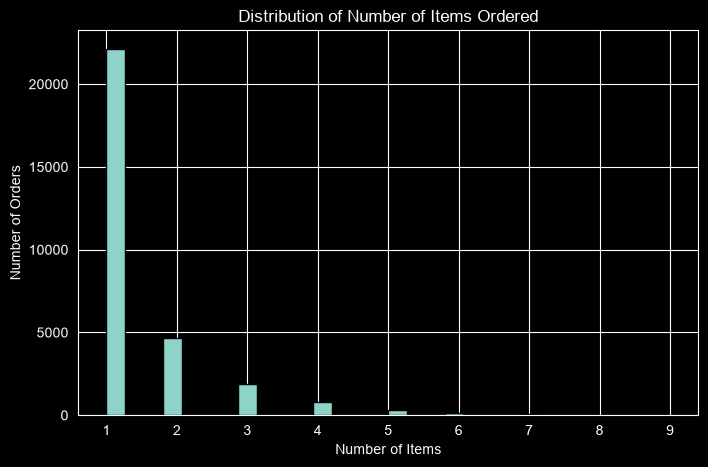

<Figure size 600x500 with 0 Axes>

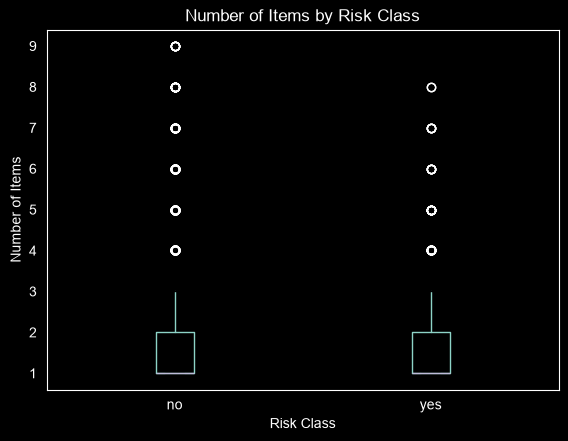

,count,mean,std,min,25%,50%,75%,max
CLASS,,,,,,,,
no,28254.0,1.439194,0.919686,1.0,1.0,1.0,2.0,9.0
yes,1746.0,1.490836,0.949243,1.0,1.0,1.0,2.0,8.0


In [62]:

# Summary Statistics
print(df1["AMOUNT_ORDER"].describe())

# Histogram
plt.figure(figsize=(8,5))

plt.hist(
    df1["AMOUNT_ORDER"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Number of Items Ordered")
plt.xlabel("Number of Items")
plt.ylabel("Number of Orders")

plt.show()

# Boxplot by CLASS
plt.figure(figsize=(6,5))

df1.boxplot(
    column="AMOUNT_ORDER",
    by="CLASS",
    grid=False
)

plt.title("Number of Items by Risk Class")
plt.suptitle("")
plt.xlabel("Risk Class")
plt.ylabel("Number of Items")

plt.show()

# Summary statistics by class
display(df1.groupby("CLASS")["AMOUNT_ORDER"].describe())

### Analysis and Interpretation

The distribution of **`AMOUNT_ORDER`** is highly positively (right) skewed. Most orders consist of **a single item**, with the frequency of orders decreasing rapidly as the number of items increases. Orders containing more than four items are relatively uncommon, while only a very small number of orders contain between six and nine items, representing high-value outliers.

Comparison of the number of items ordered across the two risk classes reveals nearly identical distributions. Both high-risk and low-risk orders share the same median (**1 item**) and interquartile range (**1–2 items**). The average number of items ordered is also very similar, with low-risk orders averaging **1.44 items** and high-risk orders averaging **1.49 items**. In addition, both classes exhibit comparable variability, as indicated by their similar standard deviations.

These findings suggest that the number of items ordered provides very little separation between high-risk and low-risk transactions. While high-risk orders contain a marginally higher average number of items, the difference is negligible and the substantial overlap between the two distributions indicates that `AMOUNT_ORDER` is a weak standalone predictor of order risk.

**Feature Decision:** ✅ Keep (for now)

**Reason:** Although `AMOUNT_ORDER` demonstrates limited standalone predictive power, it may still contribute useful information when combined with other variables in a machine learning model. Its importance should therefore be evaluated during feature selection and model training rather than being excluded based solely on exploratory data analysis.

count    30000.000000
mean        29.875652
std         57.382732
min          0.000000
25%          0.000000
50%          0.000000
75%         38.470000
max       1047.800000
Name: VALUE_ORDER_PRE, dtype: float64


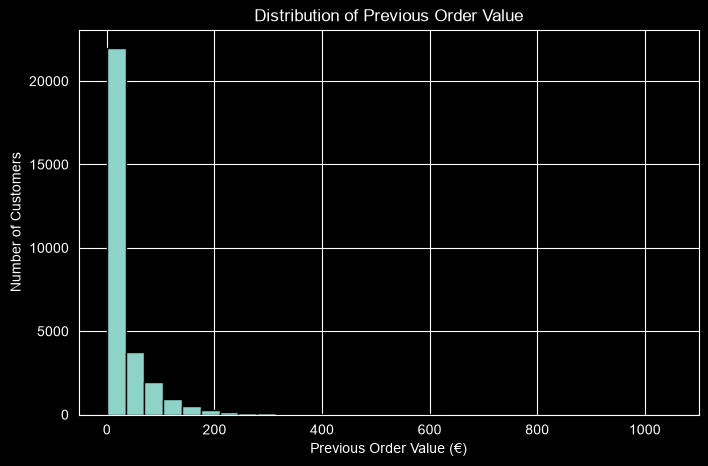

<Figure size 600x500 with 0 Axes>

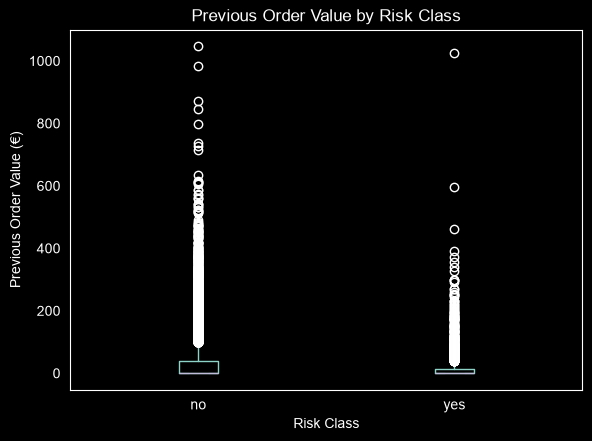

,count,mean,std,min,25%,50%,75%,max
CLASS,,,,,,,,
no,28254.0,30.430428,57.439948,0.0,0.0,0.0,39.51,1047.8
yes,1746.0,20.898190,55.701644,0.0,0.0,0.0,15.03,1024.8


In [65]:

# Summary Statistics
print(df1["VALUE_ORDER_PRE"].describe())

# Histogram
plt.figure(figsize=(8,5))

plt.hist(
    df1["VALUE_ORDER_PRE"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Previous Order Value")
plt.xlabel("Previous Order Value (€)")
plt.ylabel("Number of Customers")

plt.show()

# Boxplot by CLASS
plt.figure(figsize=(6,5))

df1.boxplot(
    column="VALUE_ORDER_PRE",
    by="CLASS",
    grid=False
)

plt.title("Previous Order Value by Risk Class")
plt.suptitle("")
plt.xlabel("Risk Class")
plt.ylabel("Previous Order Value (€)")

plt.show()

# Summary statistics by class
display(df1.groupby("CLASS")["VALUE_ORDER_PRE"].describe())

### Analysis and Interpretation

The distribution of **`VALUE_ORDER_PRE`** is highly positively (right) skewed. Most customers have very low previous order values, with more than half of the observations equal to **€0**, indicating that many customers have no recorded previous order value. A small number of customers have substantially larger historical order values, producing a long right tail and several extreme outliers exceeding **€1,000**.

Comparison across the two risk classes reveals noticeable differences in previous purchasing behaviour. Although both groups share a median previous order value of **€0**, indicating that at least half of the customers in each class have no prior recorded spending, the upper quartile differs considerably. The 75th percentile for low-risk customers is **€39.51**, compared with only **€15.03** for high-risk customers. In addition, low-risk customers exhibit a higher average previous order value (**€30.43**) than high-risk customers (**€20.90**).

These findings suggest that customers associated with low-risk orders generally have a stronger purchasing history and higher previous spending than customers associated with high-risk orders. While both classes contain customers with exceptionally large previous order values, the majority of high-risk customers appear to have limited historical purchase activity. This indicates that `VALUE_ORDER_PRE` may provide useful information for distinguishing between high-risk and low-risk orders.

**Feature Decision:** ✅ Keep

**Reason:** `VALUE_ORDER_PRE` demonstrates a meaningful difference between the two risk classes, particularly in historical spending behaviour. Customers associated with low-risk orders tend to have higher previous order values, suggesting that historical purchasing patterns may contribute useful predictive information during model development.

count    30000.000000
mean         0.606700
std          0.765616
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          6.000000
Name: AMOUNT_ORDER_PRE, dtype: float64


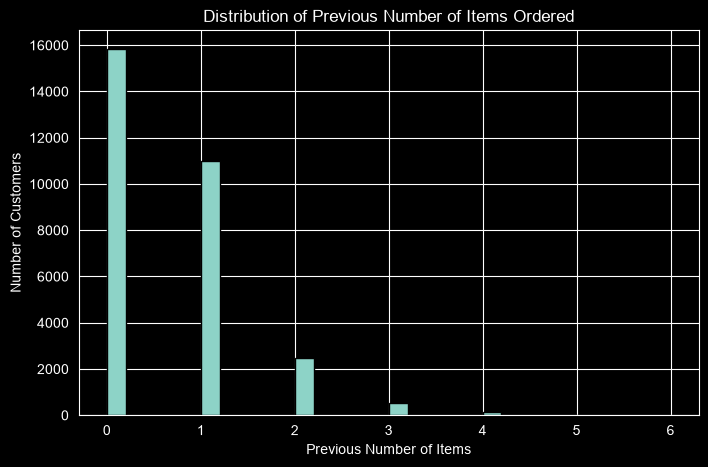

<Figure size 600x500 with 0 Axes>

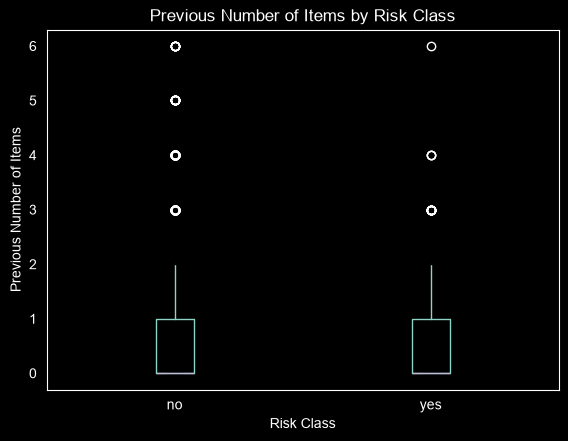

,count,mean,std,min,25%,50%,75%,max
CLASS,,,,,,,,
no,28254.0,0.619948,0.767647,0.0,0.0,0.0,1.0,6.0
yes,1746.0,0.392325,0.698035,0.0,0.0,0.0,1.0,6.0


In [66]:

# Summary Statistics
print(df1["AMOUNT_ORDER_PRE"].describe())

# Histogram
plt.figure(figsize=(8,5))

plt.hist(
    df1["AMOUNT_ORDER_PRE"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Previous Number of Items Ordered")
plt.xlabel("Previous Number of Items")
plt.ylabel("Number of Customers")

plt.show()

# Boxplot by CLASS
plt.figure(figsize=(6,5))

df1.boxplot(
    column="AMOUNT_ORDER_PRE",
    by="CLASS",
    grid=False
)

plt.title("Previous Number of Items by Risk Class")
plt.suptitle("")
plt.xlabel("Risk Class")
plt.ylabel("Previous Number of Items")

plt.show()

# Summary statistics by class
display(df1.groupby("CLASS")["AMOUNT_ORDER_PRE"].describe())

### Analysis and Interpretation

The distribution of **`AMOUNT_ORDER_PRE`** is highly positively (right) skewed. Most customers have **no previously recorded items ordered**, with the median equal to **0** and the majority of observations concentrated between **0 and 1 item**. The frequency decreases rapidly as the number of previously ordered items increases, while only a small number of customers have historical orders containing more than three items, resulting in several high-value outliers.

Comparison across the two risk classes reveals largely overlapping distributions. Both high-risk and low-risk customers share the same median (**0 previous items**) and interquartile range (**0–1 item**), indicating that most customers have little or no previous purchasing history. However, low-risk customers exhibit a slightly higher average number of previously ordered items (**0.62**) compared with high-risk customers (**0.39**), suggesting that customers associated with low-risk orders generally have a somewhat stronger purchasing history.

Overall, the difference between the two classes is modest, and the substantial overlap indicates that `AMOUNT_ORDER_PRE` is not a strong standalone predictor of order risk. Nevertheless, the consistently higher historical purchase activity among low-risk customers suggests that previous purchasing behaviour may provide additional predictive value when considered alongside other features.

**Feature Decision:** ✅ Keep

**Reason:** Although `AMOUNT_ORDER_PRE` provides only limited separation between the two risk classes, it captures aspects of historical customer behaviour that may improve predictive performance when combined with other variables. Its contribution should therefore be assessed further during feature selection and model development.

## Summary of Numerical Feature Analysis

The table below summarizes the key findings from the numerical feature analysis. The predictive strength is based on the degree of separation observed between high-risk and low-risk orders during exploratory data analysis.

| Feature | Key Observation | Predictive Strength | Decision |
|----------|-----------------|---------------------|----------|
| `VALUE_ORDER` | Current order values are very similar across the two risk classes, showing little separation. | Weak | ✅ Keep |
| `SESSION_TIME` | High-risk customers tend to have slightly shorter session times than low-risk customers. | Moderate | ✅ Keep |
| `AMOUNT_ORDER` | The number of items ordered is nearly identical across both risk classes. | Weak | ✅ Keep |
| `VALUE_ORDER_PRE` | Low-risk customers generally have higher previous order values, indicating stronger purchasing history. | Moderate to Strong | ✅ Keep |
| `AMOUNT_ORDER_PRE` | Low-risk customers have slightly more previously purchased items than high-risk customers. | Moderate | ✅ Keep |

### Key Findings

The numerical feature analysis suggests that **historical customer behaviour** (`VALUE_ORDER_PRE` and `AMOUNT_ORDER_PRE`) provides stronger discriminatory information than characteristics of the **current order** (`VALUE_ORDER` and `AMOUNT_ORDER`). While most numerical features exhibit considerable overlap between the two classes, previous purchasing behaviour and session duration demonstrate meaningful differences that may improve predictive performance when combined with other features. Consequently, all numerical features will be retained for subsequent feature selection and model development.

In [67]:
df1.isnull().sum()

ORDER_ID                 0
Z_CARD_VALID             0
VALUE_ORDER              0
AMOUNT_ORDER             0
ANUMMER_01               0
SESSION_TIME             0
AMOUNT_ORDER_PRE         0
VALUE_ORDER_PRE          0
CLASS                    0
B_EMAIL                  0
B_TELEFON                0
B_BIRTHDATE           2942
FLAG_LRIDENTISCH         0
FLAG_NEWSLETTER          0
Z_METHODE                0
Z_CARD_ART           18654
Z_LAST_NAME          14808
WEEKDAY_ORDER            0
TIME_ORDER              20
ANUMMER_02           22147
ANUMMER_03           26802
ANUMMER_04           28668
ANUMMER_05           29459
ANUMMER_06           29794
ANUMMER_07           29905
ANUMMER_08           29966
ANUMMER_09           29993
ANUMMER_10           30000
CHK_LADR                 0
CHK_RADR                 0
CHK_KTO                  0
CHK_CARD                 0
CHK_COOKIE               0
CHK_IP                   0
FAIL_LPLZ                0
FAIL_LORT                0
FAIL_LPLZORTMATCH        0
F

### Feature Selection & Engineering

count    27058.000000
mean        36.417215
std          9.633060
min         21.000000
25%         29.000000
50%         35.000000
75%         43.000000
max         73.000000
Name: AGE, dtype: float64

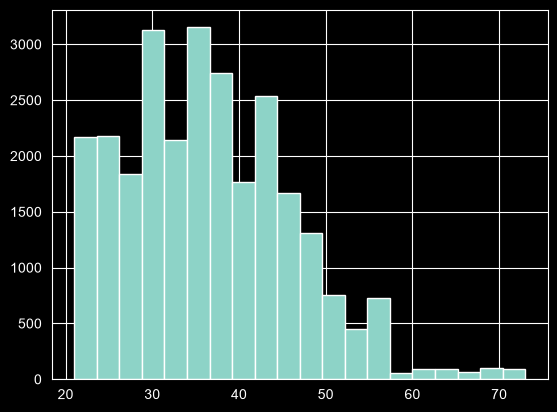

In [80]:
# Birthdate feature engineering
df1["B_BIRTHDATE"] = pd.to_datetime(df1["B_BIRTHDATE"])
df1["B_BIRTHDATE"].head()


# Create an AGE Column
df1["AGE"] = 2007 - df1["B_BIRTHDATE"].dt.year
# Plotting the Age column
import seaborn as sns
import matplotlib.pyplot as plt
df1["AGE"].hist(bins=20)
df1["AGE"].describe()


,count,unique,top,freq
CLASS,,,,
no,28254,5,31-45,13388
yes,1746,5,31-45,784


AGE_GROUP
18-30      5.827815
31-45      5.532035
46-60      6.661874
60+        5.637255
Missing    6.016315
Name: yes, dtype: float64

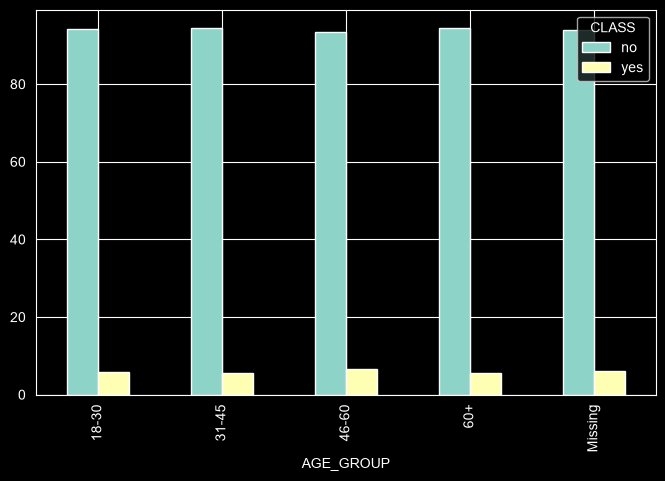

In [82]:
# Creating an AGE Group column
df1["AGE_GROUP"] = pd.cut(
    df1["AGE"],
    bins=[0,18,30,45,60,100],
    labels=["<18","18-30","31-45","46-60","60+"]
)

# Filling the missing values with missing
df1["AGE_GROUP"] = (
    df1["AGE_GROUP"]
    .cat.add_categories("Missing")
    .fillna("Missing")
)
agegroup_class_chart = (
    pd.crosstab(
        df1["AGE_GROUP"],
        df1["CLASS"],
        normalize="index"
    ) * 100
).round(2)

agegroup_class_chart.plot(kind="bar", figsize=(8,5))

# display class and age group statistics
display(df1.groupby("CLASS")["AGE_GROUP"].describe())
(
    pd.crosstab(
        df1["AGE_GROUP"],
        df1["CLASS"],
        normalize="index"
    )
    .mul(100)["yes"]
)

### Analysis and Interpretation for B_BIRTHDATE

The relationship between `AGE_GROUP` and the target variable indicates only modest differences in the proportion of high-risk orders across age categories. Customers aged **46–60** exhibit the highest high-risk rate (**6.66%**), while customers aged **31–45** have the lowest (**5.53%**). The remaining age groups are close to the overall dataset baseline of **5.82%**.

Although some variation exists, the differences between age groups are relatively small, suggesting that age alone is not a strong predictor of order risk. The substantial overlap in risk rates indicates that customer age provides limited standalone discriminatory power.

**Feature Decision:** ✅ Keep

**Reason:** While `AGE_GROUP` demonstrates only weak predictive strength, it is a more meaningful and interpretable representation of customer age than the raw birth date. It may contribute additional predictive value when combined with other features during model development.

In [87]:
df1["TIME_ORDER"].head()

#convert it to date time
df1["TIME_ORDER"] = pd.to_datetime(
    df1["TIME_ORDER"],
    format="%I:%M:%S %p",
    errors="coerce"
)

# Extract the hour
df1["ORDER_HOUR"] = df1["TIME_ORDER"].dt.hour
df1["ORDER_HOUR"].head()

0     9.0
1    17.0
2    11.0
3     2.0
4    23.0
Name: ORDER_HOUR, dtype: float64

TIME_BUCKET
Afternoon    31.88
Morning      27.98
Evening      21.67
Night        18.48
Name: proportion, dtype: float64
TIME_BUCKET
Night        6.32
Morning      5.62
Afternoon    5.72
Evening      5.80
Name: yes, dtype: float64


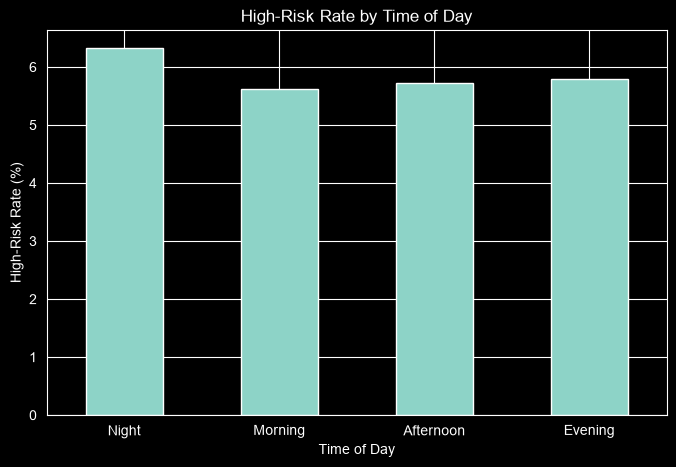

In [91]:
# Create time bucket
df1["TIME_BUCKET"] = pd.cut(
    df1["ORDER_HOUR"],
    bins=[-1, 5, 11, 17, 23],
    labels=["Night", "Morning", "Afternoon", "Evening"]
)

# Check the distribution
timebucket_distribution = (
    df1["TIME_BUCKET"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(timebucket_distribution)

# Compare with the target variable
timebucket_class = (
    pd.crosstab(
        df1["TIME_BUCKET"],
        df1["CLASS"],
        normalize="index"
    )
    .mul(100)["yes"]
    .round(2)
)

print(timebucket_class)

# Plot
timebucket_class.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("High-Risk Rate by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("High-Risk Rate (%)")

plt.xticks(rotation=0)

plt.show()

### Analysis and Interpretation

The relationship between `TIME_BUCKET` and the target variable shows only modest variation in the proportion of high-risk orders throughout the day. Orders placed during the **Night** period exhibit the highest high-risk rate (**6.32%**), while Morning (5.62%), Afternoon (5.72%), and Evening (5.80%) remain close to the overall dataset baseline of **5.82%**.

Although night-time orders appear slightly more likely to be classified as high risk, the differences across time periods are relatively small. This suggests that the time of day alone provides limited discriminatory power for predicting order risk.

**Feature Decision:** ✅ Keep

**Reason:** `TIME_BUCKET` offers a simple and interpretable representation of purchase timing. While its standalone predictive strength is weak, it may provide additional value when combined with other customer and transaction features during model development.

In [92]:
df1["DATE_LORDER"].head()

0          NaN
1          NaN
2          NaN
3    5/12/2002
4          NaN
Name: DATE_LORDER, dtype: str

In [93]:
df1["DATE_LORDER"].describe()

count         14144
unique         1500
top       3/19/2001
freq             21
Name: DATE_LORDER, dtype: object

In [94]:
df1["DATE_LORDER"].isna().sum()

np.int64(15856)

HAS_PREVIOUS_ORDER
No     52.85
Yes    47.15
Name: proportion, dtype: float64
HAS_PREVIOUS_ORDER
No     7.76
Yes    3.64
Name: yes, dtype: float64


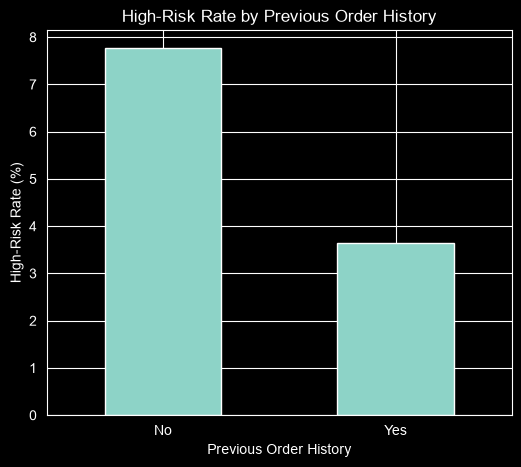

In [95]:
# Create a new feature for customers with previous order
df1["HAS_PREVIOUS_ORDER"] = (
    df1["DATE_LORDER"]
    .notna()
    .map({True: "Yes", False: "No"})
)

# Check distribution
previous_order_distribution = (
    df1["HAS_PREVIOUS_ORDER"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(previous_order_distribution)

previous_order_class = (
    pd.crosstab(
        df1["HAS_PREVIOUS_ORDER"],
        df1["CLASS"],
        normalize="index"
    )
    .mul(100)["yes"]
    .round(2)
)

print(previous_order_class)

previous_order_class.plot(
    kind="bar",
    figsize=(6, 5)
)

plt.title("High-Risk Rate by Previous Order History")
plt.xlabel("Previous Order History")
plt.ylabel("High-Risk Rate (%)")
plt.xticks(rotation=0)

plt.show()

### Analysis and Interpretation

The engineered feature `HAS_PREVIOUS_ORDER` reveals a strong relationship with the target variable. Customers without a previous recorded order have a **7.76%** high-risk rate, while customers with a previous order have a substantially lower high-risk rate of **3.64%**.

This represents a difference of more than four percentage points and indicates that customers with an established purchase history are considerably less likely to be classified as high risk. Conversely, customers without previous orders are more than twice as likely to belong to the high-risk class.

The results suggest that previous purchase history is an important indicator of customer reliability and provides meaningful predictive information for fraud detection.

**Feature Decision:** ✅ Keep `HAS_PREVIOUS_ORDER`

**Reason:** The engineered feature captures valuable customer history while avoiding the complexity of using raw calendar dates. It demonstrates strong predictive power and is more interpretable than the original `DATE_LORDER` variable. The original `DATE_LORDER` can be dropped after feature engineering.

In [100]:
print(df1["MAHN_AKT"].value_counts(dropna=False))

print("\n" + "="*50 + "\n")

print(df1["MAHN_HOECHST"].value_counts(dropna=False))

MAHN_AKT
NaN    15856
0      12703
1       1182
3        133
2        126
Name: count, dtype: int64


MAHN_HOECHST
NaN    15856
0      10200
1       2282
2       1253
3        409
Name: count, dtype: int64


MAHN_AKT
Missing    52.85
0          42.34
1           3.94
3           0.44
2           0.42
Name: proportion, dtype: float64
CLASS        no    yes
MAHN_AKT              
0         96.59   3.41
1         96.02   3.98
2         89.68  10.32
3         83.46  16.54
Missing   92.24   7.76


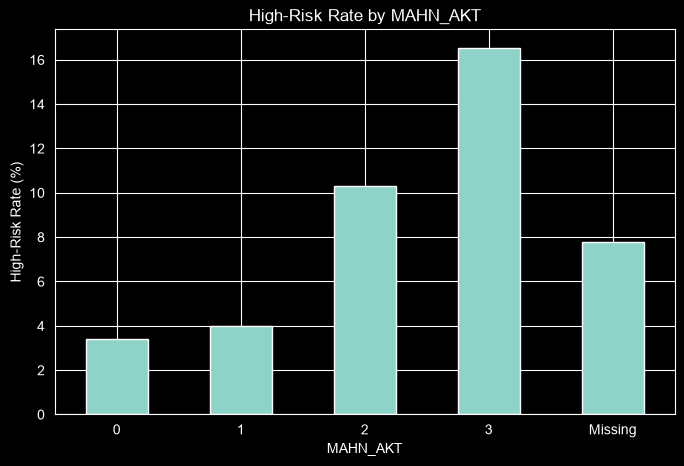

In [102]:
mahn_akt_distribution = (
    df1["MAHN_AKT"]
    .fillna("Missing")
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(mahn_akt_distribution)

mahn_akt_class = (
    pd.crosstab(
        df1["MAHN_AKT"].fillna("Missing"),
        df1["CLASS"],
        normalize="index"
    )
    .mul(100)
    .round(2)
)

print(mahn_akt_class)

mahn_akt_class["yes"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("High-Risk Rate by MAHN_AKT")
plt.xlabel("MAHN_AKT")
plt.ylabel("High-Risk Rate (%)")

plt.xticks(rotation=0)

plt.show()

MAHN_HOECHST
Missing    52.85
0          34.00
1           7.61
2           4.18
3           1.36
Name: proportion, dtype: float64
CLASS            no   yes
MAHN_HOECHST             
0             96.80  3.20
1             96.41  3.59
2             94.25  5.75
3             91.44  8.56
Missing       92.24  7.76


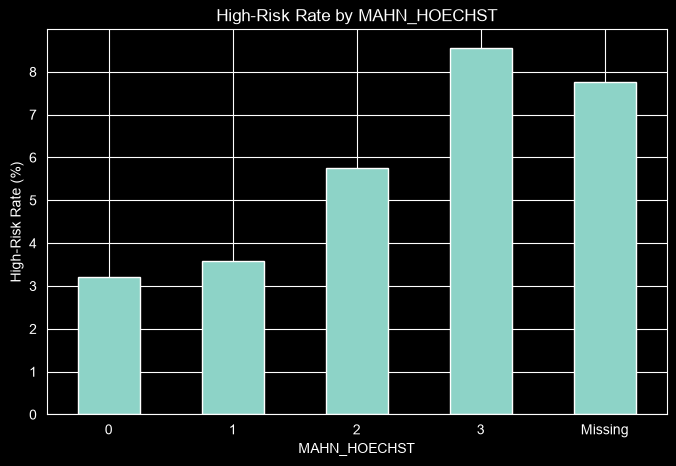

In [104]:
mahn_hoechst_distribution = (
    df1["MAHN_HOECHST"]
    .fillna("Missing")
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(mahn_hoechst_distribution)

mahn_hoechst_class = (
    pd.crosstab(
        df1["MAHN_HOECHST"].fillna("Missing"),
        df1["CLASS"],
        normalize="index"
    )
    .mul(100)
    .round(2)
)

print(mahn_hoechst_class)

mahn_hoechst_class["yes"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("High-Risk Rate by MAHN_HOECHST")
plt.xlabel("MAHN_HOECHST")
plt.ylabel("High-Risk Rate (%)")

plt.xticks(rotation=0)

plt.show()

### Analysis and Interpretation

Both `MAHN_AKT` and `MAHN_HOECHST` demonstrate meaningful relationships with the target variable.

For `MAHN_AKT`, the high-risk rate increases consistently with reminder level, rising from **3.41%** for customers with no reminders to **16.54%** for customers at reminder level 3. The missing category also exhibits a relatively high-risk rate (**7.76%**), suggesting that missing values are informative rather than random.

Similarly, `MAHN_HOECHST` shows an increasing trend in high-risk rates as the highest recorded reminder level increases, ranging from **3.20%** at level 0 to **8.56%** at level 3. Although the separation is less pronounced than for `MAHN_AKT`, the feature still provides useful predictive information.

These findings indicate that customer payment reminder history is associated with order risk and should be retained for model development.

**Feature Decision:** ✅ Keep both features.

**Missing Value Strategy:** Preserve missing values as a separate category (e.g., `"Missing"`), since the absence of reminder information appears to carry predictive value.

In [105]:
# ===============================
# Missing Value Treatment
# ===============================

# Categorical features where missing values are informative
df1["Z_LAST_NAME"] = df1["Z_LAST_NAME"].fillna("Missing")
df1["Z_CARD_ART"] = df1["Z_CARD_ART"].fillna("Missing")
df1["MAHN_AKT"] = df1["MAHN_AKT"].fillna("Missing")
df1["MAHN_HOECHST"] = df1["MAHN_HOECHST"].fillna("Missing")

# TIME_BUCKET has only 20 missing values.
# Replace them with "Unknown" to retain all observations.
df1["TIME_BUCKET"] = df1["TIME_BUCKET"].cat.add_categories(["Unknown"])
df1["TIME_BUCKET"] = df1["TIME_BUCKET"].fillna("Unknown")

## Missing Value Treatment

After completing the exploratory data analysis, missing values were handled based on the insights gained from each feature rather than applying a single imputation strategy across the dataset.

Several variables were replaced through feature engineering during EDA. Specifically, `B_BIRTHDATE` was transformed into `AGE_GROUP`, `TIME_ORDER` was represented by `TIME_BUCKET`, and `DATE_LORDER` was replaced with the engineered feature `HAS_PREVIOUS_ORDER`. As a result, missing values in these original variables no longer required direct treatment because the original features were removed from the final dataset.

For the remaining variables, different strategies were applied depending on the meaning of the missing values:

- **Informative missing values:** The missing values in `Z_LAST_NAME`, `Z_CARD_ART`, `MAHN_AKT`, and `MAHN_HOECHST` were replaced with the category **"Missing"**. During EDA, the absence of information in these features was found to be associated with different levels of order risk, indicating that the missingness itself contained predictive information.

- **Minimal missing values:** `TIME_BUCKET` contained only 20 missing observations (less than 0.1% of the dataset). These values were assigned to an **"Unknown"** category to preserve all observations while maintaining a meaningful representation of purchase time.

This feature-specific approach preserves potentially valuable information while preparing the dataset for encoding and machine learning. Rather than treating all missing values identically, each decision was guided by the statistical patterns observed during exploratory data analysis.

In [ ]:
missing_summary = (
    df1[
        [
            "Z_LAST_NAME",
            "Z_CARD_ART",
            "MAHN_AKT",
            "MAHN_HOECHST",
            "TIME_BUCKET",
        ]
    ]
    .isna()
    .sum()
)

print(missing_summary)

In [106]:
# ===============================
# Drop Unnecessary Features
# ===============================

columns_to_drop = [
    "ORDER_ID",
    "B_BIRTHDATE",
    "AGE",
    "TIME_ORDER",
    "ORDER_HOUR",
    "DATE_LORDER",
    "ANUMMER_02",
    "ANUMMER_03",
    "ANUMMER_04",
    "ANUMMER_05",
    "ANUMMER_06",
    "ANUMMER_07",
    "ANUMMER_08",
    "ANUMMER_09",
    "ANUMMER_10",
]

df1.drop(columns=columns_to_drop, inplace=True)

In [107]:
print(f"Dataset shape after dropping features: {df1.shape}")

print("\nRemaining columns:")
print(df1.columns.tolist())

Dataset shape after dropping features: (30000, 34)

Remaining columns:
['Z_CARD_VALID', 'VALUE_ORDER', 'AMOUNT_ORDER', 'ANUMMER_01', 'SESSION_TIME', 'AMOUNT_ORDER_PRE', 'VALUE_ORDER_PRE', 'CLASS', 'B_EMAIL', 'B_TELEFON', 'FLAG_LRIDENTISCH', 'FLAG_NEWSLETTER', 'Z_METHODE', 'Z_CARD_ART', 'Z_LAST_NAME', 'WEEKDAY_ORDER', 'CHK_LADR', 'CHK_RADR', 'CHK_KTO', 'CHK_CARD', 'CHK_COOKIE', 'CHK_IP', 'FAIL_LPLZ', 'FAIL_LORT', 'FAIL_LPLZORTMATCH', 'FAIL_RPLZ', 'FAIL_RORT', 'FAIL_RPLZORTMATCH', 'NEUKUNDE', 'MAHN_AKT', 'MAHN_HOECHST', 'AGE_GROUP', 'TIME_BUCKET', 'HAS_PREVIOUS_ORDER']


## Feature Removal

Following the exploratory data analysis and feature engineering process, several variables were removed from the dataset before model development.

The removed features fall into three categories:

- **Identifier variables:** `ORDER_ID` was removed because it uniquely identifies each transaction and does not provide predictive information for the classification task.

- **Replaced through feature engineering:** `B_BIRTHDATE`, `AGE`, `TIME_ORDER`, `ORDER_HOUR`, and `DATE_LORDER` were replaced with more informative engineered features (`AGE_GROUP`, `TIME_BUCKET`, and `HAS_PREVIOUS_ORDER`), making the original variables redundant.

- **Highly sparse variables:** `ANUMMER_02` through `ANUMMER_10` contained between 74% and 100% missing values. Due to their extremely high sparsity and limited potential contribution to the model, these variables were removed from the analysis.

Removing redundant and highly incomplete features reduces dataset complexity, minimizes noise, and improves the quality of the data used for model training while retaining the most informative variables identified during exploratory data analysis.

In [108]:
df1.isnull().sum().sort_values(
    ascending=False
)

Z_CARD_VALID          0
FAIL_RPLZ             0
CHK_CARD              0
CHK_COOKIE            0
CHK_IP                0
FAIL_LPLZ             0
FAIL_LORT             0
FAIL_LPLZORTMATCH     0
FAIL_RORT             0
VALUE_ORDER           0
FAIL_RPLZORTMATCH     0
NEUKUNDE              0
MAHN_AKT              0
MAHN_HOECHST          0
AGE_GROUP             0
TIME_BUCKET           0
CHK_KTO               0
CHK_RADR              0
CHK_LADR              0
WEEKDAY_ORDER         0
Z_LAST_NAME           0
Z_CARD_ART            0
Z_METHODE             0
FLAG_NEWSLETTER       0
FLAG_LRIDENTISCH      0
B_TELEFON             0
B_EMAIL               0
CLASS                 0
VALUE_ORDER_PRE       0
AMOUNT_ORDER_PRE      0
SESSION_TIME          0
ANUMMER_01            0
AMOUNT_ORDER          0
HAS_PREVIOUS_ORDER    0
dtype: int64

In [112]:
df1["CLASS"].unique()

<StringArray>
['no', 'yes']
Length: 2, dtype: str

### Data Preprocessing

In [179]:
# Seperate features and Targets
X = df1.drop(columns=["CLASS"])
y = df1["CLASS"]

print(X.shape)
print(y.shape)

(30000, 33)
(30000,)


In [180]:
# Encode the Target Variable
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

In [181]:
pd.Series(y).value_counts()

0    28254
1     1746
Name: count, dtype: int64

In [182]:
# Split numerical/categorical to apply preprocessing
cat_features = X.select_dtypes(include=["object", "category"]).columns

num_features = X.select_dtypes(include=["int64", "float64"]).columns

print(cat_features)
print(num_features)

Index(['B_EMAIL', 'B_TELEFON', 'FLAG_LRIDENTISCH', 'FLAG_NEWSLETTER',
       'Z_METHODE', 'Z_CARD_ART', 'Z_LAST_NAME', 'WEEKDAY_ORDER', 'CHK_LADR',
       'CHK_RADR', 'CHK_KTO', 'CHK_CARD', 'CHK_COOKIE', 'CHK_IP', 'FAIL_LPLZ',
       'FAIL_LORT', 'FAIL_LPLZORTMATCH', 'FAIL_RPLZ', 'FAIL_RORT',
       'FAIL_RPLZORTMATCH', 'NEUKUNDE', 'MAHN_AKT', 'MAHN_HOECHST',
       'AGE_GROUP', 'TIME_BUCKET', 'HAS_PREVIOUS_ORDER'],
      dtype='str')
Index(['Z_CARD_VALID', 'VALUE_ORDER', 'AMOUNT_ORDER', 'ANUMMER_01',
       'SESSION_TIME', 'AMOUNT_ORDER_PRE', 'VALUE_ORDER_PRE'],
      dtype='str')


In [187]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor_tree = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
        ("num", "passthrough", num_features)
    ]
)

In [188]:
# preprocessor for scaled models
from sklearn.preprocessing import StandardScaler

preprocessor_scaled = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features),
        ("num", StandardScaler(), num_features)
    ]
)

In [189]:
# Split the actual dataset

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [190]:
# Print the shapes of the training and testing sets
print("Data split successfully!")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Data split successfully!
X_train shape: (24000, 33)
X_test shape: (6000, 33)
y_train shape: (24000,)
y_test shape: (6000,)


In [191]:
X_train_tree = preprocessor_tree.fit_transform(X_train)

X_test_tree = preprocessor_tree.transform(X_test)

In [192]:
X_train_scaled = preprocessor_scaled.fit_transform(X_train)

X_test_scaled = preprocessor_scaled.transform(X_test)

## Model Training

In [193]:
# Train logistic regresssion model
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

log_model.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [194]:
# predict using it
log_pred = log_model.predict(X_test_scaled)

In [195]:
# Train decision tree
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(
    random_state=42
)

tree_model.fit(X_train_tree, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [196]:
# Predict
tree_pred = tree_model.predict(X_test_tree)

In [197]:
# Train random forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    random_state=42
)

rf_model.fit(X_train_tree, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [198]:
# Predict with random forest
rf_pred = rf_model.predict(X_test_tree)

In [199]:
# Train Gradient boosting
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    random_state=42
)

gb_model.fit(X_train_tree, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (im

In [200]:
# Predict with gradient boosting
gb_pred = gb_model.predict(X_test_tree)

### Evaluate Models


In [201]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [202]:
def evaluate_model(y_true, y_pred):
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision: {precision_score(y_true, y_pred):.4f}")
    print(f"Recall   : {recall_score(y_true, y_pred):.4f}")
    print(f"F1 Score : {f1_score(y_true, y_pred):.4f}")

In [203]:
from sklearn.metrics import classification_report

def evaluate_model(y_true, y_pred):
    print(classification_report(y_true, y_pred))

In [204]:
print("Logistic Regression")
evaluate_model(y_test, log_pred)

print("\nDecision Tree")
evaluate_model(y_test, tree_pred)

print("\nRandom Forest")
evaluate_model(y_test, rf_pred)

print("\nGradient Boosting")
evaluate_model(y_test, gb_pred)

Logistic Regression
              precision    recall  f1-score   support

           0       0.94      1.00      0.97      5651
           1       0.60      0.01      0.02       349

    accuracy                           0.94      6000
   macro avg       0.77      0.50      0.49      6000
weighted avg       0.92      0.94      0.91      6000


Decision Tree
              precision    recall  f1-score   support

           0       0.95      0.94      0.94      5651
           1       0.15      0.18      0.16       349

    accuracy                           0.89      6000
   macro avg       0.55      0.56      0.55      6000
weighted avg       0.90      0.89      0.90      6000


Random Forest
              precision    recall  f1-score   support

           0       0.94      1.00      0.97      5651
           1       0.67      0.01      0.01       349

    accuracy                           0.94      6000
   macro avg       0.80      0.50      0.49      6000
weighted avg       0.93 

## Model Tuning and Optimization

### Balance Technique

In [209]:

from sklearn.linear_model import LogisticRegression

log_model_balanced = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight="balanced"
)

log_model_balanced.fit(X_train_scaled, y_train)

log_pred_balanced = log_model_balanced.predict(X_test_scaled)

evaluate_model(y_test, log_pred_balanced)

              precision    recall  f1-score   support

           0       0.97      0.65      0.78      5651
           1       0.11      0.72      0.19       349

    accuracy                           0.65      6000
   macro avg       0.54      0.68      0.49      6000
weighted avg       0.92      0.65      0.74      6000



In [206]:
from sklearn.tree import DecisionTreeClassifier

tree_model_balanced = DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

tree_model_balanced.fit(X_train_tree, y_train)

tree_pred_balanced = tree_model_balanced.predict(X_test_tree)

evaluate_model(y_test, tree_pred_balanced)

              precision    recall  f1-score   support

           0       0.94      0.94      0.94      5651
           1       0.11      0.11      0.11       349

    accuracy                           0.90      6000
   macro avg       0.53      0.53      0.53      6000
weighted avg       0.90      0.90      0.90      6000



In [207]:
from sklearn.ensemble import RandomForestClassifier

rf_model_balanced = RandomForestClassifier(
    random_state=42,
    class_weight="balanced"
)

rf_model_balanced.fit(X_train_tree, y_train)

rf_pred_balanced = rf_model_balanced.predict(X_test_tree)

evaluate_model(y_test, rf_pred_balanced)

              precision    recall  f1-score   support

           0       0.95      0.99      0.97      5651
           1       0.31      0.09      0.14       349

    accuracy                           0.94      6000
   macro avg       0.63      0.54      0.55      6000
weighted avg       0.91      0.94      0.92      6000



### SMOTE TECHNIQUE

In [210]:
pip install imbalanced-learn


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: /Users/adunni/Desktop/order-risk-scoring-model/.venv/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [211]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

log_model_smote = LogisticRegression(
    random_state=42,
    max_iter=1000
)

log_model_smote.fit(X_train_smote, y_train_smote)

log_pred_smote = log_model_smote.predict(X_test_scaled)

evaluate_model(y_test, log_pred_smote)

              precision    recall  f1-score   support

           0       0.97      0.64      0.77      5651
           1       0.11      0.69      0.19       349

    accuracy                           0.65      6000
   macro avg       0.54      0.67      0.48      6000
weighted avg       0.92      0.65      0.74      6000



### HyperParameter Tuning

In [212]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5, 10]
}

grid = GridSearchCV(
    RandomForestClassifier(
        random_state=42,
        class_weight="balanced"
    ),
    param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

grid.fit(X_train_tree, y_train)

best_rf = grid.best_estimator_

rf_pred = best_rf.predict(X_test_tree)

evaluate_model(y_test, rf_pred)

              precision    recall  f1-score   support

           0       0.96      0.92      0.94      5651
           1       0.21      0.32      0.25       349

    accuracy                           0.89      6000
   macro avg       0.58      0.62      0.60      6000
weighted avg       0.91      0.89      0.90      6000



## Model Training and Optimization

The baseline models achieved high overall accuracy (approximately **94%**), but performed poorly on the minority class, with F1-scores between **0.01 and 0.16** for high-risk orders. Because the dataset contains only **5.8% positive cases**, accuracy alone was not an appropriate evaluation metric. The primary objective was therefore to improve the model’s ability to detect high-risk orders.

### Hyperparameter tuning

Hyperparameter tuning produced a meaningful improvement in minority-class performance. The F1-score for the positive class increased from **0.16 to 0.25**, and recall improved from **0.18 to 0.32**. This indicates that the tuned model identified substantially more high-risk orders while maintaining reasonable precision.

| Metric    | Class 0 | Class 1 |
| --------- | ------: | ------: |
| Precision |    0.96 |    0.21 |
| Recall    |    0.92 |    0.32 |
| F1-score  |    0.94 |    0.25 |

Although overall accuracy decreased from **94% to 89%**, the tuned model provided a better balance between detecting fraudulent orders and limiting false positives.

### SMOTE (Synthetic Minority Oversampling Technique)

SMOTE was then applied to oversample the minority class and create a more balanced training dataset. This resulted in a large increase in recall for high-risk orders (**0.69**), meaning the model was able to identify many more fraudulent orders. However, precision dropped sharply to **0.11**, leading to a lower F1-score of **0.19**.

| Metric    | Class 0 | Class 1 |
| --------- | ------: | ------: |
| Precision |    0.97 |    0.11 |
| Recall    |    0.64 |    0.69 |
| F1-score  |    0.77 |    0.19 |

The SMOTE model detected a much larger proportion of high-risk orders but generated a significant number of false positives, reducing overall accuracy to **65%**.

### Conclusion

For this dataset, **hyperparameter tuning produced the strongest overall improvement**, increasing the positive-class F1-score to **0.25** while maintaining a reasonable trade-off between precision and recall. SMOTE substantially improved recall, which may be valuable in applications where missing a fraudulent order is more costly than investigating additional false positives. These experiments demonstrate the importance of selecting evaluation metrics that align with the business objective rather than relying solely on accuracy when working with imbalanced classification problems.
